In [60]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as tsa_plots
from statsmodels.tsa.arima_model import ARIMA
import seaborn as sns
import requests
from bs4 import BeautifulSoup

### 364 days T-Bills data --> Path to download the data 

rbi.org.in --> statistics --> database on indian economy --> publication -->
handbook of statistics on indian economy --> series with less than monthly frequency --> list of reports --> Auction of 364 days govt of india treasury bill


In [61]:
import glob
import os
 
path="D:\TASK\CP rates\TBILL-364"
 
files = glob.glob(path + "/*.xlsx")
 
df = pd.DataFrame()
content = []
for filename in files:
    print(filename)
    # reading content of csv file
    # content.append(filename)
    data = pd.read_excel(filename)
    content.append(data)
# converting content to data frame
df = pd.concat(content)

D:\TASK\CP rates\TBILL-364\Auctions of 364-Day Government of India Treasury Bills.xlsx


In [62]:
## This function is used to remove the unwanted headers in the T-bill excel sheet and extract data
def Data_Preprocessing(a):

    b=a.iloc[8:800,1:14]
    print(b.head())

    b.columns=['Auction Date','Date of Issue','Notified Amount','Bids Received-Number','Bids Received-Total Face Value-Competitive','Bids Received-Total Face Value-Non-Competitive','Bids Accepted-Number','Bids Accepted-Total Face Value-Competitive','Bids Accepted-Total Face Value-Non-Competitive','Devolvement on PDs/SDs','Total Issue (8+9+10)','Cut-off Price','Cut-off Yield']

    c=b[b['Date of Issue'].isnull()==False][['Auction Date','Cut-off Price','Cut-off Yield']]

    df1=c.dropna(subset='Auction Date')
    a=df1.drop_duplicates()
    a.loc[a['Cut-off Yield']=="-",'Cut-off Yield']=np.nan
    a.loc[a['Cut-off Price']=="-",'Cut-off Price']=np.nan
    return a

datas=Data_Preprocessing(df)
 

             Unnamed: 1           Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5  \
8            2025-26                     NaN        NaN        NaN        NaN   
9   2025-12-24 00:00:00  2025-12-26 00:00:00       6000         67    14695.2   
10  2025-12-17 00:00:00  2025-12-18 00:00:00       6000         91      15600   
11  2025-12-10 00:00:00  2025-12-11 00:00:00       6000        100      16425   
12  2025-12-03 00:00:00  2025-12-04 00:00:00       6000        121      21691   

   Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9 Unnamed: 10 Unnamed: 11  \
8         NaN        NaN        NaN        NaN         NaN         NaN   
9     244.317         46   5755.683    244.317           -        6000   
10   1683.622         47       5700       1570           -        7270   
11    1628.71         47    5971.29    1628.71           -        7600   
12    985.486         52   5814.514    985.486           -        6800   

   Unnamed: 12 Unnamed: 13  
8          NaN         NaN  
9      94.

C:\Users\manirathinams\AppData\Local\Temp\ipykernel_28668\2544899345.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a.loc[a['Cut-off Yield']=="-",'Cut-off Yield']=np.nan
C:\Users\manirathinams\AppData\Local\Temp\ipykernel_28668\2544899345.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a.loc[a['Cut-off Price']=="-",'Cut-off Price']=np.nan


Dates=["2024-09-18","2024-09-25","2024-10-02","2024-10-09","2024-10-16","2024-10-23","2024-10-30", "2024-11-06", "2024-11-13", 
            "2024-11-20", "2024-11-27", "2024-12-04", "2024-12-11", "2024-12-18", "2024-12-25","2025-01-01", "2025-01-08", "2025-01-15", 
            "2025-01-22", "2025-01-29", "2025-02-05"]
    yields=[6.6225,6.5600,6.5487,6.5283,6.5438,6.5991,6.5991,6.5991,6.6145,6.62,6.6545, 6.5295, 6.5780, 6.6300, 6.6878, 6.6998, 6.6895, 6.7038, 6.6789, 6.6345, 6.5440]
    prices=[98.3700,98.3700,98.3400,98.3500,98.3600,98.3700,98.3800,98.3800,98.3800,98.3800,98.3800, 98.3700, 98.3200, 98.3600, 98.3700, 98.3700, 98.3700,98.3700,98.3700,98.3700, 98.3400]

In [63]:
def Additional_Data_Ingestion_Sorting(a):
    # If we want to add the cut-off yield manually for particular date we can insert in below Dates, yields and price array
    Dates=[]
    yields=[]
    prices=[]
    temp=pd.DataFrame({"Auction Date":Dates,"Cut-off Price":prices,"Cut-off Yield":yields})
    a=pd.concat([a,temp],axis=0)
    a['Auction Date']=pd.to_datetime(a['Auction Date'])
    a=a.sort_values(by='Auction Date',ascending=True)
    a.loc[a['Cut-off Price']=="-",'Cut-off Price']=np.nan
    a.loc[a['Cut-off Yield']=="-",'Cut-off Yield']=np.nan
    a=a.drop_duplicates()
    a=a.reset_index(drop=True)
    print(a.shape)
    return a

datas= Additional_Data_Ingestion_Sorting(datas)

(769, 3)


In [64]:
## Filtering the data from Jan-2010
def Data_subset(a):
    a1=a[a['Auction Date']>="2010-01-13"]
    print(a1.shape)
    return a1

datas=Data_subset(datas)

(629, 3)


In [65]:
# This function is to do the data cleaning and forward fill values in between weeks where values are null
def Equal_frequency_making(a1):
    a1=a1.set_index('Auction Date')
    a2=a1.resample('D').ffill()
    data_index = pd.date_range(start='2010-01-13', end=a2.index.max(), freq='W-WED') # 756 is the length from
    a3=pd.DataFrame({"Auction Date":data_index})
    a_1=pd.merge(left=a3,right=a2,on="Auction Date",how='left')
    a_1=a_1.set_index('Auction Date')
    a_1['Cut-off Yield']=a_1['Cut-off Yield'].fillna(method='ffill')  # Forward fill
    a_1['Cut-off Price']=a_1['Cut-off Price'].fillna(method='ffill')  # Forward fill
    a_1['Month'] = a_1.index.month.astype(str)  # Create a new column for month as strings
    return a_1

datas=Equal_frequency_making(datas)

C:\Users\manirathinams\AppData\Local\Temp\ipykernel_28668\863543997.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  a_1['Cut-off Yield']=a_1['Cut-off Yield'].fillna(method='ffill')  # Forward fill
C:\Users\manirathinams\AppData\Local\Temp\ipykernel_28668\863543997.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  a_1['Cut-off Yield']=a_1['Cut-off Yield'].fillna(method='ffill')  # Forward fill
C:\Users\manirathinams\AppData\Local\Temp\ipykernel_28668\863543997.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  a_1['Cut-off Price']=a_1['Cut-off Price'].fillna(method='ffill')  # Forward fil

In [66]:
datas.index.name='Date'
datas=datas.drop('Month',axis=1)
datas.head(3)

,Cut-off Price,Cut-off Yield
Date,,
2010-01-13,95.55,4.67
2010-01-20,95.55,4.67
2010-01-27,95.55,4.67


In [67]:
datas.tail(3)

,Cut-off Price,Cut-off Yield
Date,,
2025-12-10,94.8048,5.4949
2025-12-17,94.7963,5.5044
2025-12-24,94.7656,5.5387


In [68]:
## Uncommand this line if you want to insert the one or two data's manually in dataframe instead of loading the T-bills excel

# datas.loc[datas.index[-2], 'Cut-off Yield'] = 6.5638
# datas.loc[datas.index[-1], 'Cut-off Yield'] = 6.5409
# datas.tail()

### US- Federal Reserve Rate

In [69]:

import requests
from bs4 import BeautifulSoup

def fetch_fomc_table_bs4(url: str):
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0.0.0 Safari/537.36"
        ),
        "Accept-Language": "en-US,en;q=0.9",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    }

    with requests.Session() as s:
        s.headers.update(headers)
        try:
            resp = s.get(url, timeout=15)
            resp.raise_for_status()  # raises HTTPError for 4xx/5xx
        except requests.exceptions.RequestException as e:
            raise RuntimeError(f"Network/HTTP error fetching page: {e}")

        soup = BeautifulSoup(resp.content, "html.parser")

        # Some Wikipedia pages have multiple 'wikitable sortable' tables.
        tables = soup.find_all("table", class_="wikitable sortable")
        if not tables:
            # try plain 'wikitable'
            tables = soup.find_all("table", class_="wikitable")
        if not tables:
            raise RuntimeError("No 'wikitable' found on the page.")

        # pick the first table; adapt if you need a specific one
        table = tables[0]

        # Extract headers (optional but helpful)
        header_cells = table.find_all("tr")[0].find_all(["th", "td"])
        headers = [hc.get_text(strip=True) for hc in header_cells]

        data = []
        for tr in table.find_all("tr")[1:]:  # skip header row
            tds = tr.find_all("td")
            if not tds:
                continue
            row = [td.get_text(strip=True) for td in tds]
            # skip empty rows
            if any(cell for cell in row):
                data.append(row)

        return headers, data


if __name__ == "__main__":
    url = "https://en.wikipedia.org/wiki/History_of_Federal_Open_Market_Committee_actions"
    try:
        headers, data = fetch_fomc_table_bs4(url)
        print("Columns:", headers)
        print(f"Rows extracted: {len(data)}")
        # Example: print first 5 rows
        for r in data[:5]:
            print(r)
    except Exception as e:
        print(f"Error: {e}")


Columns: ['Date', 'Fed. Funds Rate', 'Discount Rate', 'Votes', 'Notes']
Rows extracted: 143
['December 10, 2025', '3.50%–3.75%', '3.75%', '9–3', 'Stephen Miranpreferred a higher 50-basis-point cut, whileAustan GoolsbeeandJeffrey Schmidpreferred to maintain the rate.Official statement']
['October 29, 2025', '3.75%–4.00%', '4.00%', '10–2', 'Stephen Miranpreferred a higher 50-basis-point cut, whileJeffrey Schmidpreferred to maintain the rate.Official statement']
['September 17, 2025', '4.00%–4.25%', '4.25%', '11–1', 'Stephen Miranpreferred a higher 50-basis-point cut.Official statement']
['July 30, 2025', '4.25%–4.50%', '4.50%', '9–2', 'Michelle BowmanandChristopher Wallerpreferred a 25-basis-point cut.Official statement']
['June 18, 2025', '4.25%–4.50%', '4.50%', '12–0', 'Official statement']


In [70]:

import re
import pandas as pd
import numpy as np

# Assuming these variables are already defined from your working scraping function:
# headers, data = fetch_fomc_table_bs4(url)

# Build the DataFrame with your desired column names
fed = pd.DataFrame(
    data,
    columns=['Date', 'Fed_Funds_Rate', 'Fed_Reserve_Rate', 'Votes', 'Notes']
)

# Keep only Date and Fed_Reserve_Rate
fed = fed[['Date', 'Fed_Reserve_Rate']].copy()

# Reset index
fed = fed.reset_index(drop=True)

# Convert Date to datetime (coerce invalid formats to NaT)
fed['Date'] = pd.to_datetime(fed['Date'], errors='coerce')

# Clean Fed_Reserve_Rate text:
# 1) Remove footnote brackets like [a], [1], etc.
# 2) Normalize unicode en dashes to hyphens for splitting ranges
# 3) Remove '%' symbols and extra spaces
def clean_rate_text(x: str) -> str:
    if pd.isna(x):
        return x
    x = re.sub(r'\[.*?\]', '', x)         # remove bracketed notes
    x = x.replace('–', '-')               # en dash to hyphen
    x = x.replace('−', '-')               # minus sign to hyphen (just in case)
    x = x.replace('%', '')                # remove percent sign
    return x.strip()

fed['Fed_Reserve_Rate'] = fed['Fed_Reserve_Rate'].astype(str).apply(clean_rate_text)

# Convert to float:
# - If it's a range like "5.25-5.50", take the midpoint.
# - If it's a single number like "5.50", parse directly.
# - If unparsable (e.g., "N/A"), return NaN.
def parse_rate_to_float(x: str) -> float:
    if x is None or x == '' or x.lower() in {'na', 'n/a', 'nan'}:
        return np.nan
    # Range detection (two numbers separated by '-')
    if '-' in x:
        parts = [p.strip() for p in x.split('-') if p.strip() != '']
        try:
            nums = [float(p) for p in parts]
            if len(nums) == 2:
                return (nums[0] + nums[1]) / 2.0
            # If more than two parts, fallback to first parsable
            return float(nums[0]) if nums else np.nan
        except ValueError:
            return np.nan
    # Single value
    try:
        return float(x)
    except ValueError:
        return np.nan

fed['Fed_Reserve_Rate'] = fed['Fed_Reserve_Rate'].apply(parse_rate_to_float).astype('float64')

# Show the first few rows
print(fed.head())


        Date  Fed_Reserve_Rate
0 2025-12-10              3.75
1 2025-10-29              4.00
2 2025-09-17              4.25
3 2025-07-30              4.50
4 2025-06-18              4.50


In [ ]:
# '''Load this cell if you can't web scrap the fed reserve data from the wikipedia. 
# you have to collect the fed data manually from below webiste in excel load this cell.
# https://en.wikipedia.org/wiki/History_of_Federal_Open_Market_Committee_actions'''

# fed= pd.read_excel(r"D:\TASK\CP rates\Cogencis data\US Fed Reserve rate.xlsx")
# fed=fed[['Date','Discount Rate']]
# fed['Discount Rate']= fed['Discount Rate']*100
# fed=fed.reset_index(drop=True)
# fed['Date']=pd.to_datetime(fed['Date'])
# #fed['Discount Rate']= fed['Discount Rate'].str.replace("%","")
# #fed['Discount Rate']= fed['Discount Rate'].apply(lambda x: re.sub(r'\[.*?\]', '', x))
# fed['Discount Rate']= fed['Discount Rate'].astype('float64')
# fed.rename(columns={'Discount Rate':'Fed_Reserve_Rate'}, inplace=True)
# fed.head()

In [72]:
# This cell is to convert the fed reserve data to daily format

fed= fed.sort_values('Date', ascending=True)
fed= fed.set_index('Date')
fed_daily= fed.resample('D').ffill()
fed_daily.tail()

,Fed_Reserve_Rate
Date,
2025-12-06,4.00
2025-12-07,4.00
2025-12-08,4.00
2025-12-09,4.00
2025-12-10,3.75


In [73]:
# In this cell appending the fed data into base dataframe (cut-off yield)

base= pd.merge(datas, fed_daily, left_index=True, right_index=True, how='left')
base= base.ffill()
print(base.shape)
base.head(3)

(833, 3)


,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate
Date,,,
2010-01-13,95.55,4.67,0.5
2010-01-20,95.55,4.67,0.5
2010-01-27,95.55,4.67,0.5


In [74]:
base.tail(3)

,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate
Date,,,
2025-12-10,94.8048,5.4949,3.75
2025-12-17,94.7963,5.5044,3.75
2025-12-24,94.7656,5.5387,3.75


### Monetory Rates- Bank rates, MSF & SDF

#### Path to get the data from RBI website

Home > Publication --> Handbook of Statistics on the Indian Economy --> Part I: Annual series --> Money and Banking -->
Major Monetary Policy Rates and Reserve Requirements - Bank Rate, LAF (Repo, Reverse Repo and MSF) Rates, CRR & SLR

In [75]:
monetory= pd.read_excel(r"D:\TASK\CP rates\Cogencis data\Major Monetary Policy Rates.xlsx")
monetry=monetory.iloc[7:150,1:]
monetry.rename(columns={'Unnamed: 1':'Date', 'Unnamed: 2':'Bank Rate', 'Unnamed: 3':'Repo',
                        'Unnamed: 4':'Reverse Repo', 'Unnamed: 5':'Standing Deposit Facility Rate', 
                        'Unnamed: 6':'Marginal Standing Facility Rate', 'Unnamed: 7':'Cash Reserve Ratio',
                        'Unnamed: 8':'Statutory Liquidity Ratio'}, inplace=True)

monetory.head()

d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,NaN,Major Monetary Policy Rates and Reserve Requir...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,(Per cent),NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Effective Date\n,Bank Rate,Fix Range LAF Rates,NaN,Standing Deposit Facility (SDF) Rate,Marginal Standing Facility (MSF) Rate,Cash Reserve Ratio (CRR),Statutory Liquidity Ratio (SLR)


In [76]:
# In this cell done the sorting and filling the null values in df with previous values

monetry= monetry.sort_values(by='Date',ascending=True)
monetry= monetry.replace('-',np.nan)
monetry= monetry.ffill()
monetry= monetry.bfill()
monetry.head()

C:\Users\manirathinams\AppData\Local\Temp\ipykernel_28668\422952886.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  monetry= monetry.replace('-',np.nan)


,Date,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio
149,2001-10-23,6.5,8.0,6.0,3.75,8.25,5.75,24.0
148,2001-11-03,6.5,8.0,6.0,3.75,8.25,5.75,24.0
147,2001-12-29,6.5,8.0,6.0,3.75,8.25,5.5,24.0
146,2002-03-05,6.5,8.0,6.0,3.75,8.25,5.5,24.0
145,2002-03-28,6.5,8.0,6.0,3.75,8.25,5.5,24.0


In [77]:
monetry.info()

<class 'pandas.core.frame.DataFrame'>
Index: 143 entries, 149 to 7
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date                             143 non-null    datetime64[ns]
 1   Bank Rate                        143 non-null    float64       
 2   Repo                             143 non-null    float64       
 3   Reverse Repo                     143 non-null    float64       
 4   Standing Deposit Facility Rate   143 non-null    float64       
 5   Marginal Standing Facility Rate  143 non-null    float64       
 6   Cash Reserve Ratio               143 non-null    object        
 7   Statutory Liquidity Ratio        143 non-null    float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 10.1+ KB


In [78]:
monetry['Cash Reserve Ratio']= monetry['Cash Reserve Ratio'].astype('float')
monetry['Date']=pd.to_datetime(monetry['Date'],format="%d-%m-%Y")
monetry[monetry.duplicated()==True]

,Date,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio


In [79]:
# In this cell converting the data into daily format 
monetry=monetry.drop_duplicates()
monetry1= monetry.set_index('Date')
monetry_d= monetry1.resample('D').ffill()
monetry_d.head(3)

,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio
Date,,,,,,,
2001-10-23,6.5,8.0,6.0,3.75,8.25,5.75,24.0
2001-10-24,6.5,8.0,6.0,3.75,8.25,5.75,24.0
2001-10-25,6.5,8.0,6.0,3.75,8.25,5.75,24.0


In [80]:
monetry_d.tail(3)

,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio
Date,,,,,,,
2025-12-03,5.75,5.50,3.35,5.25,5.75,3.0,18.0
2025-12-04,5.75,5.50,3.35,5.25,5.75,3.0,18.0
2025-12-05,5.50,5.25,3.35,5.00,5.50,3.0,18.0


In [81]:
## In this cell appending the monetry data into base dataframe cut-off yield.

dfrs= pd.merge(base, monetry_d, left_index=True, right_index=True, how='left')
print(dfrs.shape)
dfrs.head(2)

(833, 10)


,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio
Date,,,,,,,,,,
2010-01-13,95.55,4.67,0.5,6.0,4.75,3.25,3.75,8.25,5.0,25.0
2010-01-20,95.55,4.67,0.5,6.0,4.75,3.25,3.75,8.25,5.0,25.0


In [82]:
# Reset index to convert date index column to a normal column
dfrs.reset_index(inplace=True)
dfrs.rename(columns={'index': 'date'}, inplace=True)
dfrs.head(3)

,Date,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio
0,2010-01-13,95.55,4.67,0.5,6.0,4.75,3.25,3.75,8.25,5.0,25.0
1,2010-01-20,95.55,4.67,0.5,6.0,4.75,3.25,3.75,8.25,5.0,25.0
2,2010-01-27,95.55,4.67,0.5,6.0,4.75,3.25,3.75,8.25,5.0,25.0


### Adding LAF weekly Data

we will get this LAF weekly data from madhumitha 

In [83]:
laf_df= pd.read_excel(r"D:\TASK\CP rates\Cogencis data\LAF Weekly.xlsx")
print(laf_df.shape)
laf_df.head(3)

(1340, 43)


,Liquidity Adjustment Facility and Open Market Operations of RBI,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42
0,Year,Frequency,Net liquidity injected (outstanding including ...,Repo : End-period rate,Repo : Turnover,Repo : Average daily turnover,Repo : Outstanding turnover,Overnight repo - variable rate : Cut off rate,Overnight repo - variable rate : Turnover,Overnight repo - variable rate : Outstanding t...,...,Standing Liquidity Facility : Average daily tu...,Standing Liquidity Facility : Outstanding turn...,Special Liquidity Facility for Mutual Funds (S...,Special Liquidity Scheme for NBFCs/HFCs,Special Long - Term Repo Operations for Small ...,Special Reverse Repo,Market Stabilisation Scheme (MSS),Open Market Operations : Net sales,Open Market Operations : Sale,Open Market Operations : Purchase
1,NaN,NaN,Rs. Million,%,Rs. Million,Rs. Million,Rs. Million,%,Rs. Million,Rs. Million,...,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million
2,20000407,W,-188800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0


In [84]:
# In this cell selecting columns and forwardfill the null values and do cleaning

laf= laf_df.iloc[2:,[0,2,7,17,10,20]]
laf.rename(columns={laf.columns[0]: 'Date', laf.columns[1]: 'Net Liquidity',
                    laf.columns[2]: 'Overnight Repo Cut off', laf.columns[3]: 'Overnight Rev Repo Cut off',
                    laf.columns[4]: 'Term Repo Cut off', laf.columns[5]: 'Term Rev Repo Cut off'}, inplace=True)

laf["Overnight Repo Cut off"]=laf["Overnight Repo Cut off"].ffill()
laf["Overnight Repo Cut off"]=laf["Overnight Repo Cut off"].bfill()

laf["Overnight Rev Repo Cut off"]=laf["Overnight Rev Repo Cut off"].ffill()
laf["Overnight Rev Repo Cut off"]=laf["Overnight Rev Repo Cut off"].bfill()

laf["Term Repo Cut off"]=laf["Term Repo Cut off"].ffill()
laf["Term Repo Cut off"]=laf["Term Repo Cut off"].bfill()

laf["Term Rev Repo Cut off"]=laf["Term Rev Repo Cut off"].ffill()
laf["Term Rev Repo Cut off"]=laf["Term Rev Repo Cut off"].bfill()

laf['Date']= laf.apply(lambda row: str(row['Date'])[0:4]+'-'+str(row['Date'])[4:6]+'-'+str(row['Date'])[6:], axis=1)
laf= laf.loc[laf['Date']> '2009-12-31']
laf= laf.sort_values('Date', ascending=True)
print(laf.shape)
laf.head(5)

(836, 6)


C:\Users\manirathinams\AppData\Local\Temp\ipykernel_28668\1412068673.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  laf["Overnight Repo Cut off"]=laf["Overnight Repo Cut off"].ffill()
C:\Users\manirathinams\AppData\Local\Temp\ipykernel_28668\1412068673.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  laf["Overnight Rev Repo Cut off"]=laf["Overnight Rev Repo Cut off"].ffill()
C:\Users\manirathinams\AppData\Local\Temp\ipykernel_28668\1412068673.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will 

,Date,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off
504,2010-01-01,-882000,8.01,7.99,8.8,7.99
505,2010-01-08,-871300,8.01,7.99,8.8,7.99
506,2010-01-15,-807800,8.01,7.99,8.8,7.99
507,2010-01-22,-703300,8.01,7.99,8.8,7.99
508,2010-01-29,-882900,8.01,7.99,8.8,7.99


In [85]:
## Merging the LAF data with Base dataframe

dfrs['Date']= pd.to_datetime(dfrs['Date'], format='%Y-%m-%d')
laf['Date']= pd.to_datetime(laf['Date'], format='%Y-%m-%d')
laf.set_index('Date', inplace=True)
laf_d= laf.resample('D').ffill()
laf_d.reset_index(inplace=True)

dfs= dfrs.merge(laf_d, how='left', on='Date')
dfs.tail()

,Date,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off
828,2025-11-26,94.7692,5.5347,4.00,5.75,5.5,3.35,5.25,5.75,3.25,18.0,-1654096.5,5.51,5.49,5.51,5.49
829,2025-12-03,94.7600,5.5450,4.00,5.75,5.5,3.35,5.25,5.75,3.00,18.0,-1745696.4,5.51,5.49,5.51,5.49
830,2025-12-10,94.8048,5.4949,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1295878.3,5.51,5.49,5.51,5.24
831,2025-12-17,94.7963,5.5044,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2135341.9,5.51,5.49,5.51,5.24
832,2025-12-24,94.7656,5.5387,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1149911.7,5.26,5.49,5.26,5.24


### Adding CPI-Inflation Data (CPI- Consumer Price Index)
We will get this data from Madhumitha, CPI data is monthly data


In [ ]:
cpi_df= pd.read_excel(r"D:\TASK\CP rates\Cogencis data\CPI Inflation Monthly data.xlsx")
print(cpi_df.shape)
cpi_df.head(3)

(345, 23)


,"Consumer Price Index (CPI): Combined, Urban and Rural: General Index, Groups and Subgroups : Base Year 2012 : Index numbers",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,Year,Frequency,General Index,General Index,General Index,Food and beverages,Food and beverages,Food and beverages,"Pan, tobacco and intoxicants","Pan, tobacco and intoxicants",...,Clothing & footwear,Housing,Housing,Housing,Fuel & light,Fuel & light,Fuel & light,Miscellaneous,Miscellaneous,Miscellaneous
1,NaN,NaN,Combined,Urban,Rural,Combined,Urban,Rural,Combined,Urban,...,Rural,Combined,Urban,Rural,Combined,Urban,Rural,Combined,Urban,Rural
2,Weight,NaN,100,100,100,45.86,36.29,54.18,2.38,1.36,...,7.36,10.07,21.67,0,6.84,5.58,7.94,28.32,29.53,27.26


In [87]:
# In this cell doing data cleaning and fill the null values with forwardfill

cpi= cpi_df.iloc[3:,[0,1,2]]
cpi.rename(columns={cpi.columns[0]: 'Date', cpi.columns[1]: 'Freq', cpi.columns[2]: 'CPI Inflation'}, inplace=True)
cpi= cpi.loc[cpi['Freq']=='M']
cpi= cpi.drop('Freq', axis=1)

cpi["CPI Inflation"]= cpi["CPI Inflation"].ffill()
cpi["CPI Inflation"]= cpi["CPI Inflation"].bfill()

cpi['Date']= cpi.apply(lambda row: str(row['Date'])[0:4]+'-'+str(row['Date'])[4:6]+'-'+str(row['Date'])[6:], axis=1)
cpi= cpi.loc[cpi['Date']> '2009-12-31']
cpi= cpi.sort_values('Date', ascending=True)
print(cpi.shape)
cpi.head(5)

(179, 2)


C:\Users\manirathinams\AppData\Local\Temp\ipykernel_28668\999881680.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cpi["CPI Inflation"]= cpi["CPI Inflation"].ffill()


,Date,CPI Inflation
3,2011-01-31,89.5
4,2011-02-28,88.4
5,2011-03-31,88.4
6,2011-04-30,89.1
7,2011-05-31,89.8


In [ ]:
# NOTE (fix): CPI Inflation is released with a real-world publication lag
# (~35 days after the reference month ends, in India). Joining on calendar
# month_year without accounting for this lag lets the model "see" a CPI
# print before it would actually have been published - look-ahead bias that
# inflates backtest fit without helping genuine forward directional skill.
#
# Fix: tag each CPI value with its real release_date (month-end + lag), then
# use merge_asof (backward) so each row only picks up CPI data that would
# actually have been available on that date.

CPI_PUBLICATION_LAG_DAYS = 35  # approx. lag between reference month and MoSPI/RBI CPI release

cpi['Date'] = pd.to_datetime(cpi['Date'], format='%Y-%m-%d')
cpi = cpi.sort_values('Date')
cpi['release_date'] = cpi['Date'] + pd.Timedelta(days=CPI_PUBLICATION_LAG_DAYS)

dfs = dfs.sort_values('Date')
dfs = pd.merge_asof(
    dfs,
    cpi[['release_date', 'CPI Inflation']].rename(columns={'release_date': 'Date'}),
    on='Date', direction='backward'
)
dfs = dfs.loc[dfs['Date'] > '2010-12-31']
dfs = dfs.ffill()
print(dfs.shape)
dfs.head()


### Adding the USD/INR data

In [89]:
# This is Automated approach of downloading USD-to-INR rates from Yahoo, due to restriction we can't use this method

# import yfinance as yf

# # USD/INR data
# ticker_symbol = "USDINR=X"

# # Updata the End date
# # Get the data for the ticker
# usd = yf.download(ticker_symbol, start="2011-01-01", end="2025-12-30")

# # Display the data
# usd_df= usd.iloc[:, [1]]

# usd_df.columns.set_names(['Date', 'USDINR'], inplace=True)
# usd_df.columns = ['USDINR']
# usd_df.reset_index(inplace=True)
# usd_df.head() 

In [90]:
# This is a manual approach off downloading the USD to INR data from below RBI website
# https://www.rbi.org.in/scripts/referenceratearchive.aspx


usd_df= pd.read_excel(r"D:\TASK\CP rates\Cogencis data\USDtoINR.xlsx")
usd_df.rename(columns={'USD':'USDINR'}, inplace=True)
usd_df.head()


,Date,USDINR
0,2010-01-01,46.65
1,2010-01-04,46.51
2,2010-01-05,46.20
3,2010-01-06,46.12
4,2010-01-07,45.87


In [91]:
# Merging the USD data with base dataframe

dfs= dfs.merge(usd_df, how='left', on='Date')
dfs.tail()

,Date,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,month_year,CPI Inflation,USDINR
777,2025-11-26,94.7692,5.5347,4.00,5.75,5.5,3.35,5.25,5.75,3.25,18.0,-1654096.5,5.51,5.49,5.51,5.49,Nov-2025,197.9,89.2649
778,2025-12-03,94.7600,5.5450,4.00,5.75,5.5,3.35,5.25,5.75,3.00,18.0,-1745696.4,5.51,5.49,5.51,5.49,Dec-2025,197.9,90.2697
779,2025-12-10,94.8048,5.4949,3.75,5.75,5.5,3.35,5.25,5.75,3.00,18.0,-1295878.3,5.51,5.49,5.51,5.24,Dec-2025,197.9,89.8822
780,2025-12-17,94.7963,5.5044,3.75,5.75,5.5,3.35,5.25,5.75,3.00,18.0,-2135341.9,5.51,5.49,5.51,5.24,Dec-2025,197.9,90.3291
781,2025-12-24,94.7656,5.5387,3.75,5.75,5.5,3.35,5.25,5.75,3.00,18.0,-1149911.7,5.26,5.49,5.26,5.24,Dec-2025,197.9,89.7703


### Adding the Foreign Exchange Reserve data

This data was shared by madhumitha, Foreign Exchange Reserve is a monthly data

In [ ]:
# Loading and doing data cleaning

fer= pd.read_csv(r"D:\TASK\CP rates\Cogencis data\Foriegn Exchange Reserve Monthly data.csv")
fer= fer.iloc[:, [0,2]]
fer.rename(columns={fer.columns[0]:'Date', fer.columns[1]:'foreign_exc_resrv'}, inplace=True)
fer['Date']= fer.apply(lambda row: str(row['Date'])[0:4]+'-'+str(row['Date'])[4:6]+'-'+str(row['Date'])[6:8], axis=1)
fer= fer.loc[fer['Date']> '2009-12-31']
fer= fer.sort_values('Date', ascending=True)
fer['Date']= pd.to_datetime(fer['Date'], format='%Y-%m-%d')
fer['month_year']= fer['Date'].dt.strftime('%b-%Y')
print(fer.shape)
fer.head(5)

(191, 3)


,Date,foreign_exc_resrv,month_year
239,2010-01-31,13027930,Jan-2010
240,2010-02-28,12868480,Feb-2010
241,2010-03-31,12596650,Mar-2010
242,2010-04-30,12426910,Apr-2010
243,2010-05-31,12706100,May-2010


In [ ]:
# NOTE (fix): same look-ahead issue as CPI above. RBI FX reserve figures for
# a given reference date are published with roughly a 1-2 week lag. Use the
# same publication-lag + merge_asof approach instead of an unlagged
# month_year join.

FER_PUBLICATION_LAG_DAYS = 14

fer['Date'] = pd.to_datetime(fer['Date'], format='%Y-%m-%d')
fer = fer.sort_values('Date')
fer['release_date'] = fer['Date'] + pd.Timedelta(days=FER_PUBLICATION_LAG_DAYS)

dfs = dfs.sort_values('Date')
dfs = pd.merge_asof(
    dfs,
    fer[['release_date', 'foreign_exc_resrv']].rename(columns={'release_date': 'Date'}),
    on='Date', direction='backward'
)
dfs = dfs.ffill()
print(dfs.shape)
dfs.head(5)


### Adding call money weighted average data

we have to get this data from Madhumitha, this data is weekly data

In [ ]:
call_money= pd.read_csv(r"D:\TASK\CP rates\Cogencis data\Call Money Rate Weekly data.csv")
call_money= call_money.iloc[:, [0,4]]

call_money.rename(columns={call_money.columns[0]:'Date', call_money.columns[1]:'call_money_avg'}, inplace=True)
call_money['Date']= call_money.apply(lambda row: str(row['Date'])[0:4]+'-'+str(row['Date'])[4:6]+'-'+str(row['Date'])[6:8], axis=1)
call_money= call_money.loc[call_money['Date']> '2009-12-31']
call_money= call_money.sort_values('Date', ascending=True)

call_money['Date']= pd.to_datetime(call_money['Date'], format='%Y-%m-%d') 
call_money.set_index('Date', inplace=True)
call_money_d=call_money.resample('D').ffill()
call_money_d.reset_index(inplace=True)
print(call_money.shape)
call_money_d.head()


(836, 1)


,Date,call_money_avg
0,2010-01-01,3.3
1,2010-01-02,3.3
2,2010-01-03,3.3
3,2010-01-04,3.3
4,2010-01-05,3.3


In [95]:
# Joining the call_money_weighted_avg data with Base dataframe based on Date column
dfs= dfs.merge(call_money_d, how='left', on='Date')
print(dfs.shape)
dfs.head(5)

(782, 21)


,Date,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,...,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,month_year,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg
0,2011-01-05,93.05,7.4896,0.5,6.0,6.25,5.25,3.75,8.25,6.0,...,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.20,13749360.0,6.58
1,2011-01-12,93.04,7.5012,0.5,6.0,6.25,5.25,3.75,8.25,6.0,...,856350.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.16,13749360.0,6.52
2,2011-01-19,93.04,7.5012,0.5,6.0,6.25,5.25,3.75,8.25,6.0,...,844000.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.38,13749360.0,6.23
3,2011-01-26,92.96,7.5940,0.5,6.0,6.50,5.50,3.75,8.25,6.0,...,1180940.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.38,13749360.0,6.57
4,2011-02-02,92.96,7.5940,0.5,6.0,6.50,5.50,3.75,8.25,6.0,...,791250.0,8.01,7.99,8.8,7.99,Feb-2011,88.4,45.63,13625950.0,6.58


In [ ]:
dfs = dfs.ffill()
# month_year is no longer created on dfs (cells above now merge via
# merge_asof + publication lag instead of a month_year join), so drop
# defensively in case it's present from an older run.
dfs = dfs.drop(columns=['month_year'], errors='ignore')
dfs.tail(3)


In [97]:
# '''This cell is example of how to do hard coding and change the particular values in df, 
#  sometimes repo rate will change during time that we can use this cell'''

#dfs.loc[dfs.index[-1], 'Repo'] = 5.25
#dfs.loc[dfs.index[-1], 'Bank Rate'] = 6.50
#dfs.loc[dfs.index[-1], 'Standing Deposit Facility Rate'] = 6.0
#dfs.loc[dfs.index[-1], 'Marginal Standing Facility Rate'] = 6.50
#dfs.tail(5)

In [44]:
# # if you want to save the preprocessing workings save untill this working.
# dfs.to_csv(r"D:\TASK\CP rates\Hybrid model\364 days T-Bill final data.csv", index=False)
# print('saved successfuly!')

saved successfuly!


### Correlation Visulaization

In [98]:
# Code for correlation chart to compare the correlation between features

df1= dfs.drop(['Bank Rate', 'Cut-off Price', 'Date'], axis=1)
corr=df1.corr()
plt.figure(figsize=(15, 15),dpi=600)
g=sns.heatmap(corr, square=True, center=0, annot=True, linewidths=.5, cmap="RdBu_r", cbar_kws={"shrink": 0.8},vmin=-1,vmax=1);
#sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
g.set_xticklabels(g.get_xticklabels(),rotation=45,fontsize=8,ha='right')
plt.title("Correlation Plot : T Bill 364 Days")
plt.show()

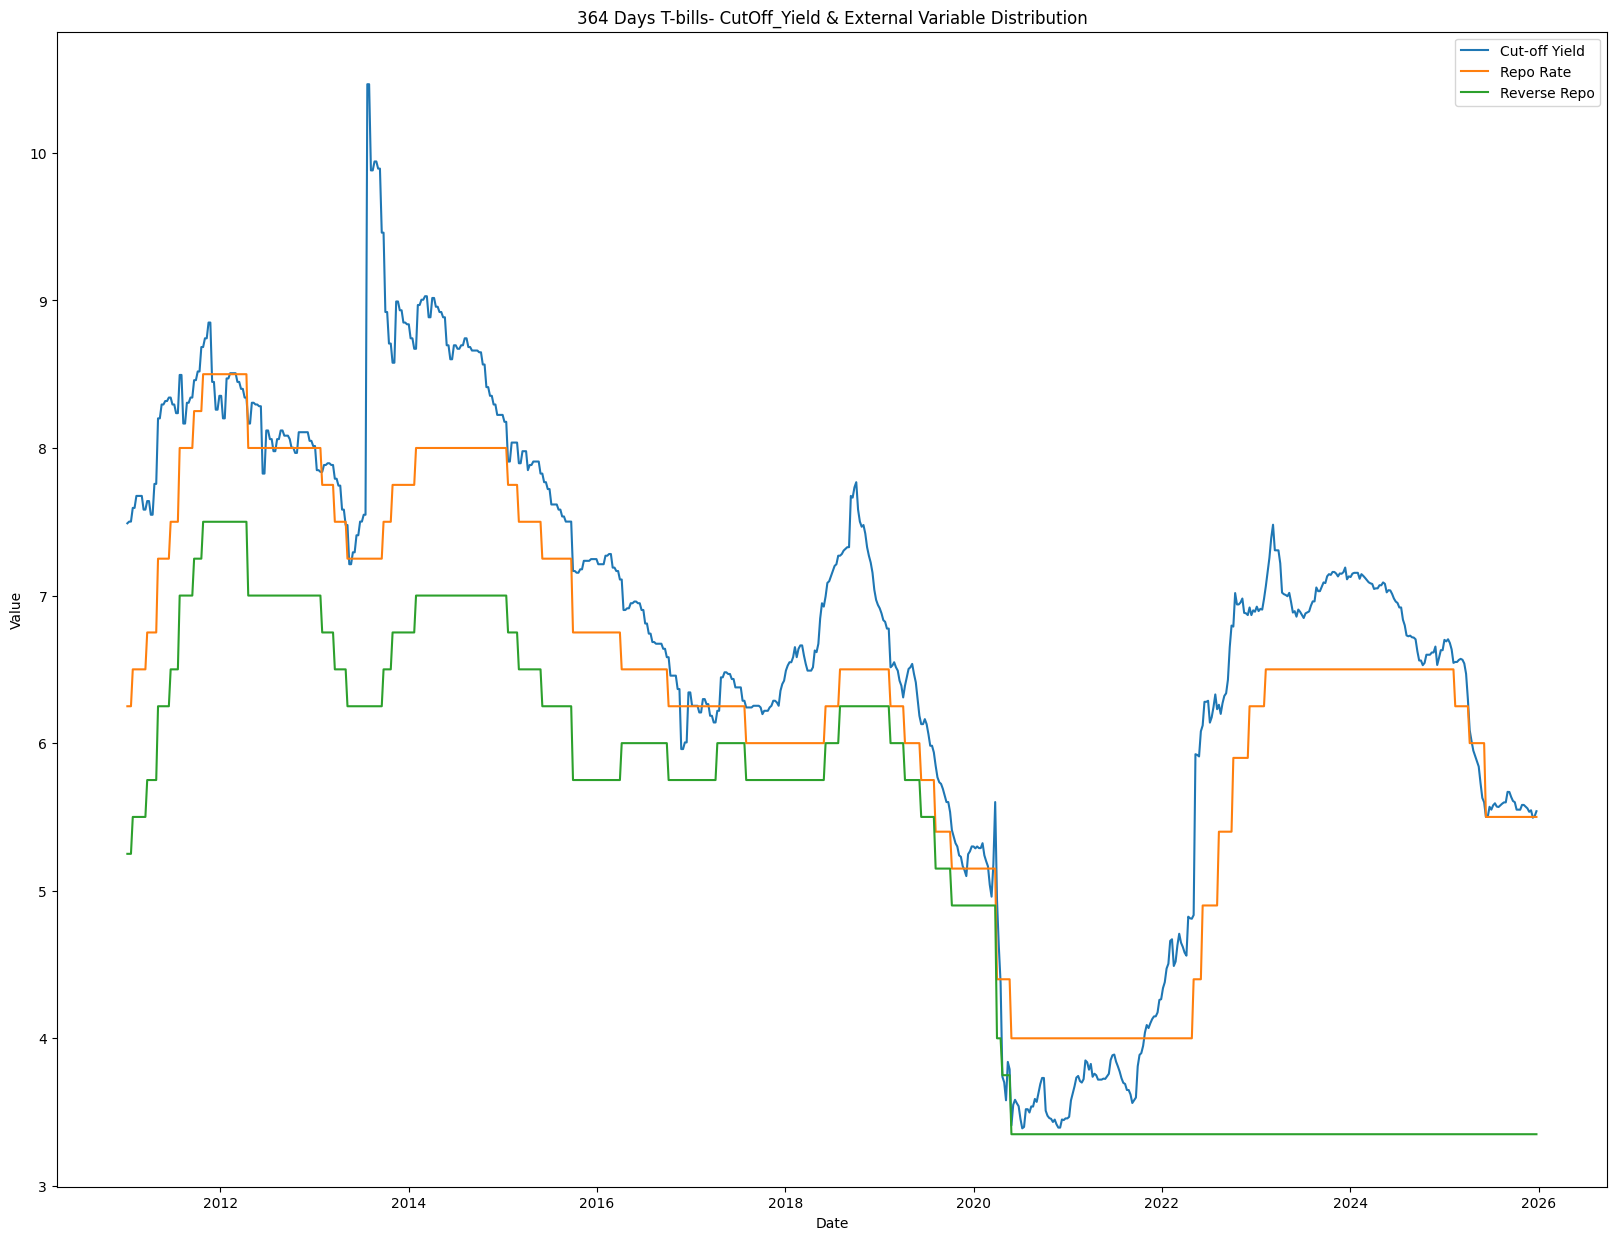

In [99]:
plt.figure(figsize=(20, 15))
plt.plot(dfs['Date'], dfs[['Cut-off Yield','Repo','Reverse Repo']])
#plt.plot(dfs['Date'], dfs['CPI Inflation']*0.010)
plt.title("364 Days T-bills- CutOff_Yield & External Variable Distribution")
plt.legend(['Cut-off Yield', 'Repo Rate', 'Reverse Repo'])
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

### AUTO-ARIMA FORECASTING 

In [100]:
from pmdarima import auto_arima
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [101]:
data= dfs.set_index('Date')
data.tail(3)

,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg
Date,,,,,,,,,,,,,,,,,,,
2025-12-10,94.8048,5.4949,3.75,5.75,5.5,3.35,5.25,5.75,3.0,18.0,-1295878.3,5.51,5.49,5.51,5.24,197.9,89.8822,61553630.0,5.38
2025-12-17,94.7963,5.5044,3.75,5.75,5.5,3.35,5.25,5.75,3.0,18.0,-2135341.9,5.51,5.49,5.51,5.24,197.9,90.3291,61553630.0,5.19
2025-12-24,94.7656,5.5387,3.75,5.75,5.5,3.35,5.25,5.75,3.0,18.0,-1149911.7,5.26,5.49,5.26,5.24,197.9,89.7703,61553630.0,5.36


In [102]:
df1= dfs.set_index('Date')

In [103]:
data.columns

Index(['Cut-off Price', 'Cut-off Yield', 'Fed_Reserve_Rate', 'Bank Rate',
       'Repo', 'Reverse Repo', 'Standing Deposit Facility Rate',
       'Marginal Standing Facility Rate', 'Cash Reserve Ratio',
       'Statutory Liquidity Ratio', 'Net Liquidity', 'Overnight Repo Cut off',
       'Overnight Rev Repo Cut off', 'Term Repo Cut off',
       'Term Rev Repo Cut off', 'CPI Inflation', 'USDINR', 'foreign_exc_resrv',
       'call_money_avg'],
      dtype='object')

In [104]:
# removing some unwanted columns
data= data.drop(['Bank Rate','Cut-off Price'], axis=1)
data.head(3)

,Cut-off Yield,Fed_Reserve_Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg
Date,,,,,,,,,,,,,,,,,
2011-01-05,7.4896,0.5,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,89.5,45.20,13749360.0,6.58
2011-01-12,7.5012,0.5,6.25,5.25,3.75,8.25,6.0,24.0,856350.0,8.01,7.99,8.8,7.99,89.5,45.16,13749360.0,6.52
2011-01-19,7.5012,0.5,6.25,5.25,3.75,8.25,6.0,24.0,844000.0,8.01,7.99,8.8,7.99,89.5,45.38,13749360.0,6.23


In [ ]:
# getting the month and day of the year columns, plus lagged macro features
import pandas as pd
import calendar

def create_feature(df):
    df.index = pd.to_datetime(df.index)
    df['quarter'] = df.index.quarter
    df['Month'] = df.index.month
    df['dayofyear'] = df.index.dayofyear
    return df

def encode_quarter_finQuarter(data):
    data.loc[data['quarter']==1,'quarter']='Q4'
    data.loc[data['quarter']==2,'quarter']='Q1'
    data.loc[data['quarter']==3,'quarter']='Q2'
    data.loc[data['quarter']==4,'quarter']='Q3'
    return data

def encode_finQuarter_num(data):
    data.loc[data['quarter']=='Q4','quarter']=4
    data.loc[data['quarter']=='Q1','quarter']=1
    data.loc[data['quarter']=='Q2','quarter']=2
    data.loc[data['quarter']=='Q3','quarter']=3
    return data

# NOTE (new): lagged versions of the key macro drivers. Yields typically
# react to policy/liquidity signals with a lag rather than contemporaneously,
# so exposing lag-1 and lag-4 (week) versions alongside the current value
# lets auto_arima pick up whichever lag actually carries signal.
LAG_COLS = ['Repo', 'Reverse Repo', 'CPI Inflation', 'USDINR', 'Net Liquidity', 'call_money_avg']
LAGS = [1, 4]

def add_lag_features(df, cols=LAG_COLS, lags=LAGS):
    for col in cols:
        if col in df.columns:
            for lag in lags:
                df[f'{col}_lag{lag}'] = df[col].shift(lag)
    return df

def Merging_feature_engg_with_data(h23):
    h23 = create_feature(h23)
    h23 = encode_quarter_finQuarter(h23)
    h23 = encode_finQuarter_num(h23)
    h23['quarter'] = h23['quarter'].astype('int')
    h23 = add_lag_features(h23)
    return h23

data = Merging_feature_engg_with_data(data)
# bfill only affects the first max(LAGS) rows, which are the only ones with
# NaNs introduced by the lag shift; ffill still handles the original gaps.
data = data.ffill().bfill()
data.tail(4)


## Modify

In [106]:
# This code is useful for backtesting, To run forecasting upto particular date

#data= data[data.index <='2024-05-31']
#data.tail()

### Performing Dickey-Fuller Test

To check data is stationary or non stationary

In [107]:
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test
def adf_test(timeseries):
    # Perform Dickey-Fuller test:
    adf_result = adfuller(timeseries, autolag='AIC')
    
    # Print ADF test results
    print('ADF Statistic: {:.4f}'.format(adf_result[0]))
    print('p-value: {:.4f}'.format(adf_result[1]))
    print('Critical Values:')
    for key, value in adf_result[4].items():
        print('\t{}: {:.4f}'.format(key, value))

# Assuming 'Yield' column is the one you want to test for stationarity
adf_test(data['Cut-off Yield'])

ADF Statistic: -1.3343
p-value: 0.6133
Critical Values:
	1%: -3.4389
	5%: -2.8653
	10%: -2.5688


The p-value 0.6131 is greater than 0.05 for a significance level of 5%, indicating rejects the H1-(alternate hypothesis) and accepting the H0-(null hypothesis). Therefore, the data is likely non-stationary. it might require differencing or other transformations to achieve stationarity.

In [ ]:
# NOTE (new): KPSS as a cross-check on the ADF result above. ADF's null
# hypothesis is "has a unit root" (non-stationary); KPSS's null hypothesis
# is the OPPOSITE ("is stationary"). Using both avoids over-trusting a
# single test on a rate series that can behave like a regime-shifting /
# near-unit-root process rather than a textbook random walk.
from statsmodels.tsa.stattools import kpss

def kpss_test(timeseries):
    statistic, p_value, n_lags, critical_values = kpss(timeseries, regression='c', nlags='auto')
    print('KPSS Statistic: {:.4f}'.format(statistic))
    print('p-value: {:.4f}'.format(p_value))
    print('Critical Values:')
    for key, value in critical_values.items():
        print('\t{}: {:.4f}'.format(key, value))
    if p_value < 0.05:
        print('=> KPSS suggests NON-stationary (agrees with the ADF result above)')
    else:
        print('=> KPSS suggests stationary - conflicts with ADF; worth investigating '
              '(e.g. trend-stationary vs difference-stationary) before fixing d')

kpss_test(data['Cut-off Yield'])


In [ ]:
# NOTE (fix): previously StandardScaler was applied to only 5 of ~18
# exogenous columns (Net Liquidity, CPI, USDINR, FX reserves, call money),
# leaving Repo/Reverse Repo/Fed rate/SDF/MSF/CRR/SLR on raw scale. For the
# exogenous-regression component of SARIMAX this unevenly influences
# coefficient estimation. Scale ALL continuous macro columns consistently;
# calendar dummies (quarter/Month/dayofyear) and the target itself are
# intentionally left unscaled. The fitted scalers are kept so the exact
# same transform can be applied to the future exogenous data later
# (avoids a train/inference scale mismatch).
from sklearn.preprocessing import StandardScaler

CONTINUOUS_EXOG_COLS = [
    'Repo', 'Reverse Repo', 'Fed_Reserve_Rate', 'Standing Deposit Facility Rate',
    'Marginal Standing Facility Rate', 'Cash Reserve Ratio', 'Statutory Liquidity Ratio',
    'Net Liquidity', 'Overnight Repo Cut off', 'Overnight Rev Repo Cut off',
    'Term Repo Cut off', 'Term Rev Repo Cut off', 'CPI Inflation', 'USDINR',
    'foreign_exc_resrv', 'call_money_avg',
]
# also scale the lag columns created above, with their own fitted scaler
CONTINUOUS_EXOG_COLS += [c for c in data.columns if c.endswith(tuple(f'_lag{l}' for l in LAGS))]

scalers = {}
for col in CONTINUOUS_EXOG_COLS:
    if col in data.columns:
        scaler = StandardScaler()
        data[col] = scaler.fit_transform(data[[col]])
        scalers[col] = scaler

data.head(3)


In [ ]:
# Selecting the macroeconomic factors (+ their lagged versions) as
# exogenous features to pass into the ARIMA model
exog_cols = ['Repo', 'Reverse Repo','Fed_Reserve_Rate', 'Standing Deposit Facility Rate',
             'Marginal Standing Facility Rate', 'Cash Reserve Ratio',
             'Statutory Liquidity Ratio', 'Net Liquidity', 'Overnight Repo Cut off',
              'Overnight Rev Repo Cut off', 'Term Repo Cut off', 'Term Rev Repo Cut off','CPI Inflation', 'USDINR',
              'foreign_exc_resrv', 'call_money_avg', 'quarter','Month','dayofyear']
exog_cols += [c for c in data.columns if c.endswith(tuple(f'_lag{l}' for l in LAGS))]

# NOTE (fix): d is no longer hard-coded to 1. Previously test='adf' was
# passed to auto_arima but immediately overridden by d=1, so the ADF/KPSS
# test results above were never actually used to pick the differencing
# order. Now auto_arima's own stationarity test decides d.
model = auto_arima(data['Cut-off Yield'], X=data[exog_cols], seasonal=False, m=52,
                    test='adf', trace=True, stepwise=True, D=None)


In [110]:
# Print model summary
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  782
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 432.724
Date:                Wed, 07 Jan 2026   AIC                           -825.447
Time:                        15:20:37   BIC                           -732.235
Sample:                    01-05-2011   HQIC                          -789.599
                         - 12-24-2025                                         
Covariance Type:                  opg                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Repo                               -0.3435      0.185     -1.853      0.064      -0.707       0.020
Reverse Repo                        0.7439      0.152      4.897    

In [ ]:
# ---------------------------------------------------------------------------
# NOTE (main fix): forecasting FUTURE exogenous variables instead of
# flat-lining them.
#
# Previously every exog column - including CPI, Net Liquidity, USDINR, FX
# reserves, call money, AND the policy rates - was held at its last observed
# value for the whole 25-week horizon. Since auto_arima's own multi-step
# forecast on a differenced series flattens out quickly, holding every
# driver flat as well left no directional signal anywhere in the forecast -
# which is exactly the "tight variance, no directional alignment" symptom.
#
# Fix:
#   1. Continuous, non-policy-controlled macro series (CPI, Net Liquidity,
#      USDINR, FX reserves, call money, LAF cut-offs) are forecast forward
#      with their own small auto_arima model instead of carried flat.
#   2. Policy-controlled step-function rates (Repo, Reverse Repo, Fed rate,
#      SDF, MSF, CRR, SLR) are held flat ONLY until the next scheduled
#      meeting date, at which point you can supply an expected / market-
#      implied change via POLICY_RATE_OVERRIDES below. This stops the
#      "rate never changes" assumption from silently running across a
#      whole 6-month horizon when in reality 1-2 MPC/FOMC meetings will
#      fall inside it.
# ---------------------------------------------------------------------------

FORECASTABLE_COLS = ['CPI Inflation', 'USDINR', 'foreign_exc_resrv', 'call_money_avg',
                      'Net Liquidity', 'Overnight Repo Cut off', 'Overnight Rev Repo Cut off',
                      'Term Repo Cut off', 'Term Rev Repo Cut off']

POLICY_RATE_COLS = ['Repo', 'Reverse Repo', 'Fed_Reserve_Rate',
                     'Standing Deposit Facility Rate', 'Marginal Standing Facility Rate',
                     'Cash Reserve Ratio', 'Statutory Liquidity Ratio']

# Fill in known/expected MPC or FOMC decisions here as they're announced or
# as your house view forms. Values are in the SAME (scaled) units as the
# `data` columns, since cell 63 scaled these columns before the model was
# fit. Leave a column out entirely to fall back to a flat carry (the old
# behaviour) for that column.
#
# Example:
# POLICY_RATE_OVERRIDES = {
#     'Repo': [('2025-04-09', 6.25), ('2025-06-06', 6.00)],
# }
POLICY_RATE_OVERRIDES = {}


def forecast_series_forward(series, n_periods):
    """Fit a small univariate auto_arima on one macro series and forecast n_periods ahead,
    instead of assuming it stays flat."""
    series = series.dropna()
    try:
        m = auto_arima(series, seasonal=False, stepwise=True,
                        suppress_warnings=True, error_action='ignore')
        fcast = m.predict(n_periods=n_periods)
        return np.asarray(fcast)
    except Exception as e:
        print(f"  [warn] univariate forecast for this column failed ({e}); falling back to flat carry")
        return np.repeat(series.iloc[-1], n_periods)


def apply_policy_overrides(col, last_value, future_dates):
    """Flat carry, stepping to override values on/after their effective date."""
    values = np.repeat(last_value, len(future_dates))
    for eff_date, new_value in POLICY_RATE_OVERRIDES.get(col, []):
        eff_date = pd.Timestamp(eff_date)
        mask = future_dates >= eff_date
        values[mask] = new_value
    return values


def Future_independet_Variables(h24, n_periods=25):
    Future_Date = pd.date_range(start=h24.index[-1], periods=n_periods + 1, freq='W-WED')
    Future_Date = Future_Date[1:]
    Future = pd.DataFrame({"Date": Future_Date}).set_index("Date")

    print("Forecasting forward paths for continuous macro exogenous variables...")
    for col in FORECASTABLE_COLS:
        if col in h24.columns:
            print(f"  forecasting {col}")
            Future[col] = forecast_series_forward(h24[col], len(Future_Date))

    print("Applying policy-rate paths (flat-carry with scheduled overrides)...")
    for col in POLICY_RATE_COLS:
        if col in h24.columns:
            Future[col] = apply_policy_overrides(col, h24[col].iloc[-1], Future.index)

    # Lag features need real history to be correct for the first few future
    # rows, so stitch on the tail of actual history before computing lags,
    # then slice the future rows back out.
    lookback = max(LAGS)
    combined = pd.concat([h24[Future.columns].tail(lookback), Future])
    combined = Merging_feature_engg_with_data(combined)
    Future = combined.tail(len(Future_Date))
    return Future


future_exog = Future_independet_Variables(data)
future_exog.tail()


In [112]:
# Get forecast
#forecast_steps = 26 Number of steps to forecast(forecasting cut-off yield of 26 weeks)

forecast, conf_int = model.predict(n_periods=len(future_exog), X= future_exog, return_conf_int=True)


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [113]:
forecast
# Dataframe for forecasted data
preds= pd.DataFrame(forecast, columns=['Forecasted'])
preds

,Forecasted
2025-12-31,5.538186
2026-01-07,5.543934
2026-01-14,5.543420
2026-01-21,5.542906
2026-01-28,5.542392
2026-02-04,5.544656
2026-02-11,5.544142
2026-02-18,5.543628
2026-02-25,5.543114
2026-03-04,5.545377


## ------------ End ---------------

### Model Evaluation code

In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse=np.sqrt(mean_squared_error(final['CutOff_Yield'], final['Forecasted']))
mae= mean_absolute_error(final['CutOff_Yield'], final['Forecasted'])
print(f'RMSE score:{rmse}')
print(f'MAE score:{mae}')

RMSE score:0.052114244773971426
MAE score:0.04189618873228799


In [ ]:
# NOTE (new): RMSE/MAE alone are magnitude metrics - they will happily
# reward a forecast that stays flat near the last known value even if it
# never anticipates a turn. Add a directional accuracy / hit-ratio metric
# that actually measures what you're missing.
actual_diff = final['CutOff_Yield'].diff()
forecast_diff = final['Forecasted'].diff()

direction_match = np.sign(actual_diff) == np.sign(forecast_diff)
directional_accuracy = direction_match.mean() * 100

print(f'Directional accuracy: {directional_accuracy:.1f}% of periods')


In [ ]:
# ---------------------------------------------------------------------------
# NOTE (new): walk-forward backtest with directional accuracy.
#
# A single train/test split (as used for the RMSE/MAE above) rewards a
# forecast that stays flat near the last known value - exactly the failure
# mode described (low variance, no directional skill). An expanding-window
# walk-forward backtest, refit at each step, is a much more honest test of
# whether the forward-exog fix in Future_independet_Variables() actually
# restores directional signal.
#
# This is left as a template/example rather than auto-run, since refitting
# auto_arima at every step over a long history can be slow - tune
# initial_train_periods/step to your data size before running.
# ---------------------------------------------------------------------------

def walk_forward_backtest(full_data, exog_cols, target_col='Cut-off Yield',
                           initial_train_periods=200, horizon=1, step=4):
    results = []
    n = len(full_data)
    for start in range(initial_train_periods, n - horizon, step):
        train = full_data.iloc[:start]
        test = full_data.iloc[start:start + horizon]

        m = auto_arima(train[target_col], X=train[exog_cols], seasonal=False,
                        stepwise=True, suppress_warnings=True, error_action='ignore')
        fcast = m.predict(n_periods=horizon, X=test[exog_cols])

        results.append({
            'date': test.index[-1],
            'actual': test[target_col].iloc[-1],
            'forecast': fcast[-1],
            'prev_actual': train[target_col].iloc[-1],
        })

    bt = pd.DataFrame(results)
    bt['actual_direction'] = np.sign(bt['actual'] - bt['prev_actual'])
    bt['forecast_direction'] = np.sign(bt['forecast'] - bt['prev_actual'])
    bt['direction_correct'] = bt['actual_direction'] == bt['forecast_direction']

    rmse = np.sqrt(mean_squared_error(bt['actual'], bt['forecast']))
    mae = mean_absolute_error(bt['actual'], bt['forecast'])
    hit_ratio = bt['direction_correct'].mean() * 100

    print(f"Walk-forward RMSE: {rmse:.4f}")
    print(f"Walk-forward MAE:  {mae:.4f}")
    print(f"Walk-forward directional hit ratio: {hit_ratio:.1f}%")
    return bt

# Example usage (adjust initial_train_periods/step to your data length first):
# backtest_results = walk_forward_backtest(data, exog_cols, initial_train_periods=200, step=4)


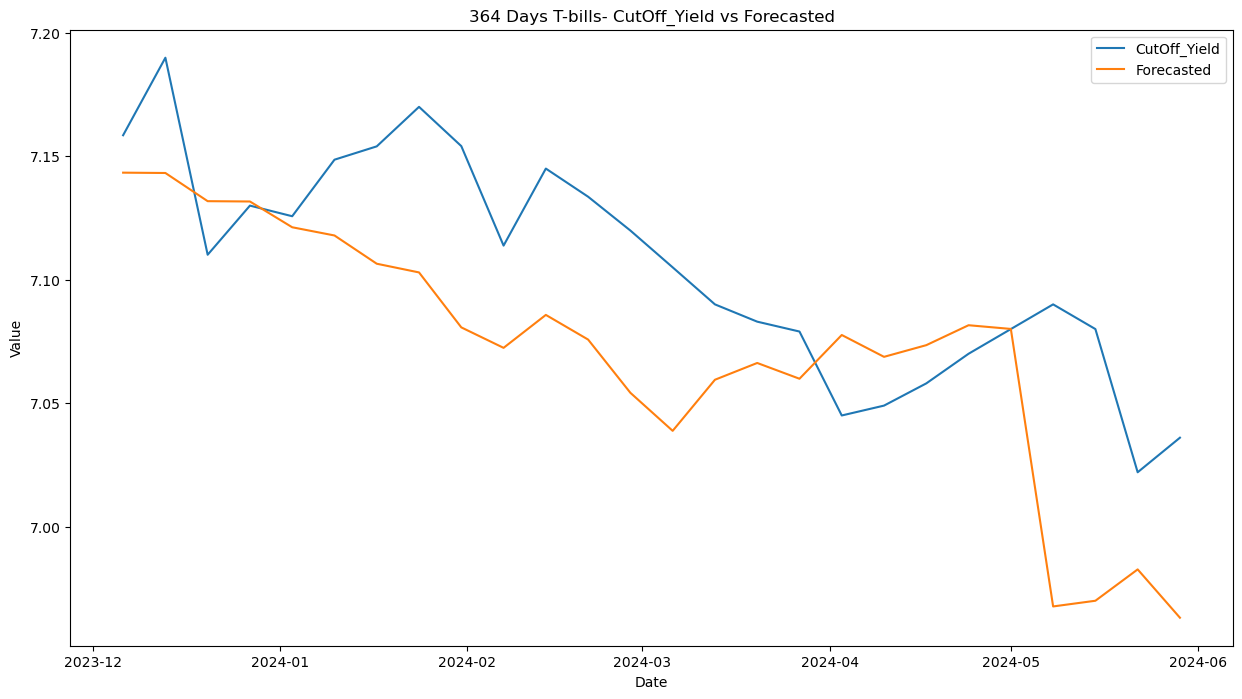

In [59]:
plt.figure(figsize=(15, 8))
plt.plot(final.index, final[['CutOff_Yield', 'Forecasted']])
plt.title("364 Days T-bills- CutOff_Yield vs Forecasted")
plt.legend(['CutOff_Yield', 'Forecasted'])
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

In [46]:
filename='D:\TASK\CP rates\Repo_external.xlsx'
df.to_excel(filename, index=False)
print('saved successfully')

saved successfully
